# ¿Cuánto vale esta casa?

**Grupo:** Calveyra, Desivo, Giordanelli, Rickert

## Milestone 1 — La tabla de decisiones

Primero cargamos el dataset y lo inspeccionamos para tener la evidencia (tipos, cardinalidad, faltantes) que respalda las decisiones de la tabla.

In [1]:
import pandas as pd

df = pd.read_csv('house-prices-extended.csv')
print(df.shape)
df.head()

(1460, 20)


,ListingId,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,YearBuilt,LotFrontage,MonthSold,State,District,HouseStyle,CentralAir,SaleCondition,SalePrice
0,677742,8450,7,5,856,2,1,3,8,0,548,1970,64.0,7,IL,Larkspur,Townhouse,N,Normal,172700
1,551423,9600,6,8,1262,2,0,3,6,1,460,1935,73.0,11,CA,Greenfield,2Story,Y,Normal,369700
2,237268,11250,7,5,920,2,1,3,6,1,608,1949,80.0,9,AZ,Fernwood,1Story,Y,Normal,165700
3,579284,9550,7,5,756,1,0,3,7,1,642,1924,72.0,7,FL,Stonegate,2Story,Y,Normal,164300
4,598125,14260,8,5,1145,2,1,4,9,1,836,1951,87.0,2,NC,Xavier Park,Loft,Y,Normal,283700


In [2]:
resumen = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unicos': df.nunique(),
    'n_faltantes': df.isna().sum(),
    'pct_faltantes': (100 * df.isna().mean()).round(2),
})
resumen

,dtype,n_unicos,n_faltantes,pct_faltantes
ListingId,int64,1460,0,0.00
LotArea,int64,1073,0,0.00
OverallQual,int64,10,0,0.00
OverallCond,int64,9,0,0.00
TotalBsmtSF,int64,721,0,0.00
FullBath,int64,4,0,0.00
HalfBath,int64,3,0,0.00
BedroomAbvGr,int64,8,0,0.00
TotRmsAbvGrd,int64,12,0,0.00
Fireplaces,int64,4,0,0.00


### Tabla de decisiones

| Columna | Qué es | Qué significa la resta entre dos valores | Cardinalidad | ¿Puede faltar? | ¿Disponible al predecir? | Codificación elegida | Motivo |
|---|---|---|---|---|---|---|---|
| `ListingId` | Identificador correlativo de la fila | Nada: es un número de carga, no una magnitud | 1460 (todos únicos) | No | Sí, pero no debe usarse | **Se descarta**, no entra como feature | Es un índice, no información de la casa. Si entra, la red puede "memorizar" el orden de carga en vez de aprender patrones — **trampa 1** (ver Pregunta 3) |
| `LotArea` | Superficie del lote (pies²) | Diferencia real de superficie | Continua, muchos valores | No | Sí | Numérica, escalada | Magnitud continua, la escala favorece el entrenamiento |
| `OverallQual` | Calidad general de material/acabado (1–10) | Un punto más de calidad | 10 | No | Sí | Numérica, escalada | Ordinal con paso uniforme, se puede tratar como continua |
| `OverallCond` | Condición general (1–9) | Un punto más de condición | 9 | No | Sí | Numérica, escalada | Ídem `OverallQual` |
| `TotalBsmtSF` | Superficie de sótano (pies²) | Diferencia real de superficie | Continua | No | Sí | Numérica, escalada | Magnitud continua |
| `FullBath` | Baños completos sobre nivel de suelo | Un baño completo más | 4 | No | Sí | Numérica, escalada | Conteo, la resta es significativa |
| `HalfBath` | Medios baños sobre nivel de suelo | Un medio baño más | 3 | No | Sí | Numérica, escalada | Conteo |
| `BedroomAbvGr` | Dormitorios sobre nivel de suelo | Un dormitorio más | 8 | No | Sí | Numérica, escalada | Conteo |
| `TotRmsAbvGrd` | Habitaciones totales sobre nivel de suelo | Una habitación más | 12 | No | Sí | Numérica, escalada | Conteo |
| `Fireplaces` | Chimeneas | Una chimenea más | 4 | No | Sí | Numérica, escalada | Conteo |
| `GarageArea` | Superficie de garage (pies²) | Diferencia real de superficie | Continua | No | Sí | Numérica, escalada | Magnitud continua |
| `YearBuilt` | Año de construcción | Antigüedad relativa entre dos casas | Continua (años) | No | Sí | Numérica, escalada | El año ya es lineal en el tiempo, no hace falta transformarlo |
| `LotFrontage` | Frente del lote (pies) | Diferencia real de frente | Continua | **Sí, ~7%** | Sí (cuando está) | Numérica escalada + imputación por mediana del conjunto de entrenamiento + indicador binario de faltante | Falta de forma no trivial; comparamos contra imputar con 0 y probamos si el faltante en sí informa (Milestone 2, Pregunta 4) |
| `MonthSold` | Mes de venta (1–12) | Nada lineal: diciembre y enero están a un mes de distancia, no a once | 12 | No | Sí | Seno/coseno (codificación cíclica) | Es una variable **cíclica** — **trampa 2**: tratarla como entero plano le asigna una distancia falsa a los meses que están en los extremos del año |
| `State` | Estado donde está la casa | Nada, es nominal | 12 | No | Sí | One-hot | Cardinalidad baja/moderada, sin orden natural — el one-hot no le impone ninguna relación entre estados |
| `District` | Distrito dentro del estado | Nada, es nominal | 72 | No | Sí | Embedding aprendido | Cardinalidad alta — un one-hot de 72 columnas es viable pero disperso; el embedding aprende una representación densa. Si se codifica como entero 0–71 la red asume un orden y una distancia entre distritos que no existen — **trampa 3** (ver Pregunta 2) |
| `HouseStyle` | Estilo arquitectónico de la casa | Nada, es nominal | 6 | No | Sí | One-hot | Cardinalidad baja, sin orden |
| `CentralAir` | Tiene aire acondicionado central (Y/N) | Nada, es binaria | 2 | No | Sí | Binaria 0/1 | Dos categorías, mapeo directo sin necesidad de one-hot |
| `SaleCondition` | Condición de la venta (normal, embargo, etc.) | Nada, es nominal | 5 | No | Sí | One-hot | Cardinalidad baja, sin orden natural entre condiciones |
| `SalePrice` | Precio de venta (dólares) | Diferencia real de precio | Continua | No | — (es el target) | Salida de la red, no se codifica como entrada | Es lo que queremos predecir: define la capa de salida (activación lineal) y la loss de regresión |





> **Las tres trampas** de este dataset son `ListingId` (identificador tratado como feature), `MonthSold` (variable cíclica tratada como lineal) y `District` (alta cardinalidad tratada como si tuviera orden). Las tres entrenan igual si se las pasa por alto — el problema aparece recién al mirar el error o al llevar el modelo a producción.

## Milestone 2 — Baseline numérico

Entrenamos una primera red usando **solo las columnas de tipo numérico** de la tabla anterior: `LotArea`, `OverallQual`, `OverallCond`, `TotalBsmtSF`, `FullBath`, `HalfBath`, `BedroomAbvGr`, `TotRmsAbvGrd`, `Fireplaces`, `GarageArea`, `YearBuilt`, `LotFrontage` y `MonthSold` (todavía como entero plano, sin seno/coseno — esa corrección la hacemos junto con las categóricas en el Milestone 3).

`ListingId` queda afuera porque ya decidimos en la tabla que es un identificador, no una feature — salvo en el experimento del final de esta sección, donde lo dejamos entrar a propósito para responder la Pregunta 3.

Este es el **piso**: el número contra el que se va a medir todo lo que agreguemos después (categóricas en el Milestone 3, regularización en el Milestone 4).

In [3]:
from sklearn.model_selection import train_test_split

NUMERIC_COLS = ['LotArea', 'OverallQual', 'OverallCond', 'TotalBsmtSF', 'FullBath',
                'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageArea',
                'YearBuilt', 'LotFrontage', 'MonthSold']
TARGET = 'SalePrice'
SEED = 42

# Partimos el dataset ANTES de calcular cualquier estadística (mediana, media, desvío).
# 70% train / 20% validation / 10% test.
df_train, df_val_test = train_test_split(df, test_size=0.3, random_state=SEED)
df_val, df_test = train_test_split(df_val_test, test_size=1/3, random_state=SEED)

print(f"train: {df_train.shape}, val: {df_val.shape}, test: {df_test.shape}")

train: (1022, 20), val: (292, 20), test: (146, 20)


### `LotFrontage`: falta en ~7% de las filas

Imputamos con la **mediana de `df_train`** — nunca con una estadística calculada sobre todo el dataset, porque eso sería mirar información de validación/test antes de entrenar (data leakage, el tema de la Pregunta 5).

Antes de imputar, guardamos un indicador binario `LotFrontage_missing` (1 si el valor faltaba, 0 si no) como feature adicional. La idea es que la ausencia del dato podría no ser aleatoria — quizás las casas donde no se registró el frente del lote comparten algo (un tipo de vivienda, una época de carga de datos) que es en sí mismo informativo.

Abajo entrenamos variantes para responder la **Pregunta 4** con evidencia:

1. **Mediana + indicador** (la que usamos como baseline "oficial").
2. **Mediana sin indicador.**
3. **Cero sin indicador** — para mostrar qué le pasa al modelo cuando un faltante se disfraza de una medida real.
4. **Mediana por grupos de `LotArea` + indicador.**
5. **Mediana por grupos de `LotArea` sin indicador.**

La imputación por grupos se probó porque `LotArea` y `LotFrontage` tienen una correlación alta (~0,83). El indicador `LotFrontage_missing` permite evaluar si el hecho de que falte el dato aporta información adicional.


In [4]:
faltantes = df[df["LotFrontage"].isna()]

print(f"Cantidad de filas: {len(faltantes)}")


Cantidad de filas: 103


In [5]:
pd.reset_option("display.max_rows")
df_analisis = df.copy()

df_analisis["LotFrontage_missing"] = (
    df_analisis["LotFrontage"].isna().astype(int)
)
df_analisis = df.copy()

df_analisis["LotFrontage_missing"] = (
    df_analisis["LotFrontage"].isna().astype(int)
)
corr = df_analisis.select_dtypes(include="number").corr()

corr_missing = (
    corr["LotFrontage_missing"]
    .sort_values()
)

display(corr_missing)

YearBuilt             -0.079489
SalePrice             -0.064013
OverallQual           -0.044943
GarageArea            -0.044590
FullBath              -0.039836
TotRmsAbvGrd          -0.031828
TotalBsmtSF           -0.022745
HalfBath              -0.012963
OverallCond           -0.007839
BedroomAbvGr           0.005762
MonthSold              0.009616
Fireplaces             0.011869
ListingId              0.014300
LotArea                0.018722
LotFrontage_missing    1.000000
LotFrontage                 NaN
Name: LotFrontage_missing, dtype: float64

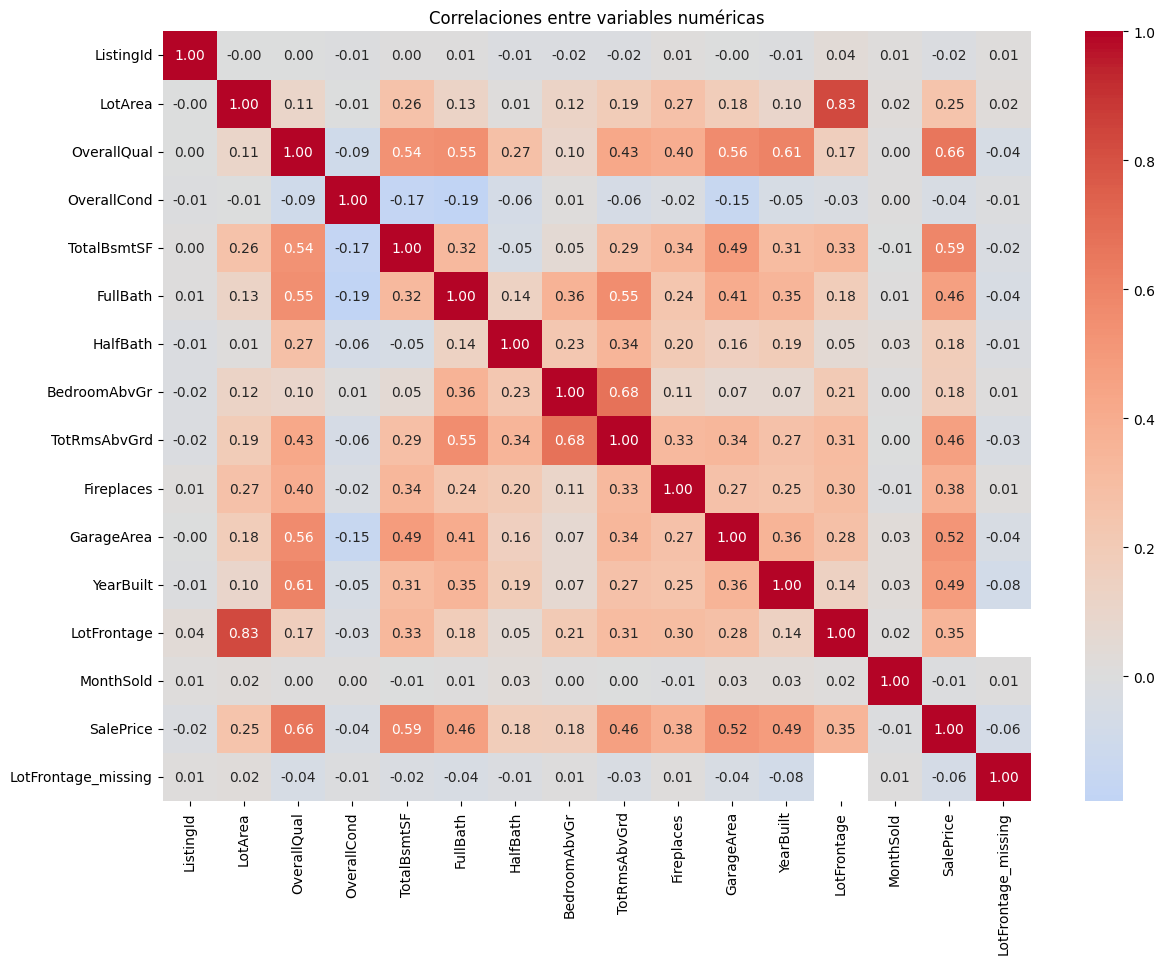

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_analisis.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlaciones entre variables numéricas")
plt.show()

El heatmap muestra que `LotFrontage` tiene una correlación alta con `LotArea` (~0,83), por eso probamos una imputación por grupos de tamaño de lote. En cambio, `LotFrontage_missing` presenta correlaciones muy bajas con el resto de las variables, incluyendo `SalePrice` (~-0,06), por lo que la ausencia del dato no parece aportar una señal fuerte.

In [7]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# TensorFlow reconfigura su propio logger al importarse, así que el nivel se
# fija DESPUÉS del import de keras (si no, queda pisado). Esto solo silencia
# avisos informativos de rendimiento (p. ej. "tf.function retracing"), no errores.
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

lotfrontage_median = df_train['LotFrontage'].median()
print(f"Mediana de LotFrontage en train: {lotfrontage_median}")

def fit_lotarea_imputer(frame, n_groups=5):
    """Ajusta en train los cortes de LotArea y la mediana de
    LotFrontage dentro de cada grupo."""
    _, bins = pd.qcut(frame['LotArea'], q=n_groups, retbins=True, duplicates='drop')
    bins = bins.copy()
    bins[0], bins[-1] = -np.inf, np.inf
    groups = pd.cut(frame['LotArea'], bins=bins, labels=False, include_lowest=True)
    medians = frame.assign(_LotAreaGroup=groups).groupby('_LotAreaGroup', observed=False)['LotFrontage'].median()
    return {'bins': bins, 'medians': medians, 'fallback': frame['LotFrontage'].median()}

def impute_lotfrontage_by_lotarea(frame, imputer):
    groups = pd.cut(frame['LotArea'], bins=imputer['bins'], labels=False, include_lowest=True)
    group_values = groups.map(imputer['medians'])
    fill_values = group_values.fillna(imputer['fallback'])
    return frame['LotFrontage'].fillna(fill_values)

def prepare_numeric_split(frame, fill_value, add_indicator, scaler=None, fit_scaler=False, lotarea_imputer=None):
    """Imputa LotFrontage, arma el indicador de faltante y escala con un scaler
    que se AJUSTA una sola vez (sobre train) y se reutiliza para las demás partes."""
    frame = frame.copy()
    missing_flag = frame['LotFrontage'].isna().to_numpy(dtype=float)
    if lotarea_imputer is None:
        frame['LotFrontage'] = frame['LotFrontage'].fillna(fill_value)
    else:
        frame['LotFrontage'] = impute_lotfrontage_by_lotarea(frame, lotarea_imputer)
    X_num = frame[NUMERIC_COLS].to_numpy(dtype=float)
    if fit_scaler:
        scaler = StandardScaler().fit(X_num)
    X_num_scaled = scaler.transform(X_num)
    X = np.column_stack([X_num_scaled, missing_flag]) if add_indicator else X_num_scaled
    y = frame[TARGET].to_numpy(dtype=float)
    return X, y, scaler

def build_baseline_model(n_features):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(32, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear'),
    ])
    # Salida real -> activación lineal + loss de regresión (mse). 'accuracy' no aplica acá:
    # no hay clases que acertar, hay una distancia en dólares que minimizar.
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_and_report(fill_value, add_indicator, epochs=100, verbose=0, lotarea_imputer=None):
    X_train, y_train_raw, scaler = prepare_numeric_split(df_train, fill_value, add_indicator, fit_scaler=True, lotarea_imputer=lotarea_imputer)
    X_val, y_val_raw, _ = prepare_numeric_split(df_val, fill_value, add_indicator, scaler=scaler, lotarea_imputer=lotarea_imputer)
    X_test, y_test_raw, _ = prepare_numeric_split(df_test, fill_value, add_indicator, scaler=scaler, lotarea_imputer=lotarea_imputer)

    # SalePrice va de ~50 mil a ~1,6 millones: sin escalar el target, el gradiente
    # tiene que moverse en un rango enorme y la red no converge en 100 épocas.
    # Escalamos y TAMBIÉN ajustando el scaler solo con train, y deshacemos el
    # escalado sobre las predicciones para reportar todo en dólares.
    y_scaler = StandardScaler().fit(y_train_raw.reshape(-1, 1))
    y_train = y_scaler.transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val = y_scaler.transform(y_val_raw.reshape(-1, 1)).ravel()

    keras.utils.set_random_seed(SEED)
    model = build_baseline_model(X_train.shape[1])
    hist = model.fit(X_train, y_train, batch_size=32, epochs=epochs,
                      validation_data=(X_val, y_val), verbose=verbose)

    y_pred_scaled = model.predict(X_test, verbose=0).ravel()
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    mae = mean_absolute_error(y_test_raw, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    mape = 100 * mean_absolute_percentage_error(y_test_raw, y_pred)
    return {'model': model, 'history': hist, 'scaler': scaler, 'y_scaler': y_scaler,
            'mae': mae, 'rmse': rmse, 'mape': mape,
            'X_test': X_test, 'y_test': y_test_raw, 'y_pred': y_pred}

Mediana de LotFrontage en train: 70.0


In [8]:
lotarea_imputer = fit_lotarea_imputer(df_train, n_groups=5)

In [9]:
print("\nMedianas de LotFrontage por grupo de LotArea:")

bins = lotarea_imputer["bins"]
medians = lotarea_imputer["medians"]

for i, median in medians.items():
    print(
        f"Grupo {int(i) + 1}: "
        f"LotArea entre {bins[int(i)]:,.0f} y {bins[int(i) + 1]:,.0f} "
        f"-> mediana LotFrontage: {median:.1f}"
    )

print(f"\nMediana global de respaldo: {lotarea_imputer['fallback']:.1f}")


Medianas de LotFrontage por grupo de LotArea:
Grupo 1: LotArea entre -inf y 7,106 -> mediana LotFrontage: 51.0
Grupo 2: LotArea entre 7,106 y 8,874 -> mediana LotFrontage: 64.0
Grupo 3: LotArea entre 8,874 y 10,318 -> mediana LotFrontage: 70.0
Grupo 4: LotArea entre 10,318 y 12,208 -> mediana LotFrontage: 77.0
Grupo 5: LotArea entre 12,208 y inf -> mediana LotFrontage: 90.0

Mediana global de respaldo: 70.0


In [10]:
lotarea_imputer = fit_lotarea_imputer(df_train, n_groups=5)

variant_median_flag = train_and_report(
    lotfrontage_median,
    add_indicator=True
)

variant_median_noflag = train_and_report(
    lotfrontage_median,
    add_indicator=False
)

variant_zero_noflag = train_and_report(
    0.0,
    add_indicator=False
)

variant_lotarea_group_flag = train_and_report(
    None,
    add_indicator=True,
    lotarea_imputer=lotarea_imputer
)

variant_lotarea_group_noflag = train_and_report(
    None,
    add_indicator=False,
    lotarea_imputer=lotarea_imputer
)

print(f"{'Variante':35} {'MAE':>12} {'RMSE':>12} {'MAPE %':>8}")
print("-" * 70)

results = [
    ("Mediana global + indicador", variant_median_flag),
    ("Mediana global sin indicador", variant_median_noflag),
    ("Cero sin indicador", variant_zero_noflag),
    ("Mediana por LotArea + indicador", variant_lotarea_group_flag),
    ("Mediana por LotArea sin indicador", variant_lotarea_group_noflag),
]

for name, result in results:
    print(
        f"{name:35} "
        f"{result['mae']:12,.0f} "
        f"{result['rmse']:12,.0f} "
        f"{result['mape']:8.2f}"
    )

Variante                                     MAE         RMSE   MAPE %
----------------------------------------------------------------------
Mediana global + indicador                51,411       69,919    27.66
Mediana global sin indicador              50,940       68,271    27.20
Cero sin indicador                        47,440       65,206    24.98
Mediana por LotArea + indicador           54,150       73,405    29.18
Mediana por LotArea sin indicador         51,071       68,121    27.21


In [11]:
missing_flag_full = df_train['LotFrontage'].isna()
corr_missing_price = missing_flag_full.astype(int).corr(df_train['SalePrice'])
media_con_dato = df_train.loc[~missing_flag_full, 'SalePrice'].mean()
media_sin_dato = df_train.loc[missing_flag_full, 'SalePrice'].mean()

print(f"Correlación entre 'falta LotFrontage' y SalePrice: {corr_missing_price:.3f}")
print(f"Precio promedio cuando SÍ está el dato: ${media_con_dato:,.0f}")
print(f"Precio promedio cuando FALTA el dato:   ${media_sin_dato:,.0f}")
print(f"Diferencia: {100 * (media_sin_dato / media_con_dato - 1):.1f}%")

Correlación entre 'falta LotFrontage' y SalePrice: -0.064
Precio promedio cuando SÍ está el dato: $213,592
Precio promedio cuando FALTA el dato:   $184,285
Diferencia: -13.7%


In [12]:
df_train_plot = df_train.copy()
df_train_plot['LotFrontage_missing'] = df_train_plot['LotFrontage'].isna().map({
    False: 'No falta',
    True: 'Falta'
})

<Figure size 800x500 with 0 Axes>

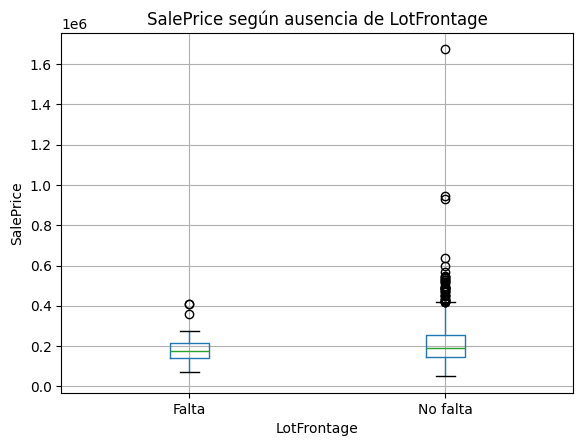

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df_train_plot.boxplot(column='SalePrice', by='LotFrontage_missing')

plt.title('SalePrice según ausencia de LotFrontage')
plt.suptitle('')  # saca el título automático de pandas
plt.xlabel('LotFrontage')
plt.ylabel('SalePrice')
plt.show()

### Pregunta 4 — Lo que falta

**¿Con qué completamos `LotFrontage`?**  
Con la mediana sin indicador calculada sobre `df_train`.

**Mediana contra cero.**  
Imputar con `0` obtuvo el menor error en esta corrida, pero para la red ese valor significa que el frente del lote mide realmente cero, y no que el dato es desconocido. Por eso preferimos una imputación con la **mediana global**, que representa un valor plausible.

También probamos usar medianas según grupos de `LotArea`, debido a su alta correlación con `LotFrontage` (~0,83), pero no produjo una mejora clara respecto de la mediana global.

**¿La ausencia dice algo por sí sola?**  
La correlación entre `LotFrontage_missing` y `SalePrice` fue muy baja (`r ≈ -0,064`). Aunque las casas con el dato faltante tuvieron un precio promedio aproximadamente 13,7% menor, agregar el indicador de faltante no mejoró las métricas del modelo. Por lo tanto, no encontramos evidencia clara de que la ausencia aporte información predictiva adicional.

### El baseline oficial

De acá en adelante, el **baseline numérico** de la misión es la variante de **mediana global sin indicador** (`variant_median_noflag`). Es la que sigue la decisión tomada anteriormente. Con ese modelo mostramos la curva de pérdida y reportamos las tres métricas de regresión sobre test.

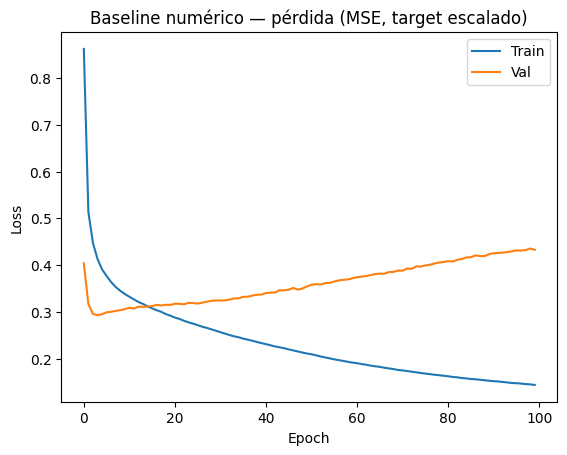

In [14]:
import matplotlib.pyplot as plt

baseline = variant_median_noflag

plt.plot(baseline['history'].history['loss'])
plt.plot(baseline['history'].history['val_loss'])
plt.title('Baseline numérico — pérdida (MSE, target escalado)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

El `val_loss` tiene su mínimo muy temprano (alrededor de la época 3) y después sube de forma sostenida, mientras el `train_loss` sigue bajando durante las 100 épocas: esto **es sobreajuste**, ya presente en este baseline tan simple, porque no usamos ningún freno (dropout, L2, early stopping). Es un problema distinto al de la Pregunta 1: acá el modelo tiene más capacidad de la que necesita y memoriza en vez de generalizar. No se arregla agregando columnas — se arregla restringiendo al modelo, que es justamente lo que vamos a hacer a propósito en el **Milestone 4**. Lo dejamos así por ahora para poder mostrar la corrección más adelante con un antes y un después.

In [15]:
print(f"MAE  (test): ${baseline['mae']:,.0f}")
print(f"RMSE (test): ${baseline['rmse']:,.0f}")
print(f"MAPE (test): {baseline['mape']:.2f}%")

MAE  (test): $50,940
RMSE (test): $68,271
MAPE (test): 27.20%


In [16]:
# ¿Qué casa de test separa más al MAE del RMSE?
# RMSE castiga el CUADRADO del error: una sola casa con un error enorme mueve el
# RMSE mucho más de lo que mueve al MAE. La buscamos como la de mayor error absoluto.
errores_abs = np.abs(baseline['y_test'] - baseline['y_pred'])
idx_peor = np.argmax(errores_abs)

df_test_reset = df_test.reset_index(drop=False)
casa_peor = df_test_reset.iloc[idx_peor]

print("Casa con el mayor error absoluto del conjunto de prueba:")
print(casa_peor[['ListingId', 'SalePrice'] + NUMERIC_COLS + ['State', 'District', 'HouseStyle']])
print(f"\nPrecio real:      ${baseline['y_test'][idx_peor]:,.0f}")
print(f"Precio predicho:  ${baseline['y_pred'][idx_peor]:,.0f}")
print(f"Error absoluto:   ${errores_abs[idx_peor]:,.0f}")

# Cuánto mueve esta única casa al RMSE, comparado con cuánto mueve al MAE
mae_sin_esa_casa = np.mean(np.delete(errores_abs, idx_peor))
rmse_sin_esa_casa = np.sqrt(np.mean(np.delete(errores_abs, idx_peor) ** 2))
print(f"\nMAE  con esa casa: ${baseline['mae']:,.0f}   |  MAE  sin esa casa: ${mae_sin_esa_casa:,.0f}"
      f"   ({100 * (1 - mae_sin_esa_casa / baseline['mae']):.1f}% menos)")
print(f"RMSE con esa casa: ${baseline['rmse']:,.0f}   |  RMSE sin esa casa: ${rmse_sin_esa_casa:,.0f}"
      f"   ({100 * (1 - rmse_sin_esa_casa / baseline['rmse']):.1f}% menos)")

Casa con el mayor error absoluto del conjunto de prueba:
ListingId           781978
SalePrice           357100
LotArea              16056
OverallQual              9
OverallCond              5
TotalBsmtSF           1992
FullBath                 3
HalfBath                 1
BedroomAbvGr             4
TotRmsAbvGrd            11
Fireplaces               1
GarageArea             716
YearBuilt             1963
LotFrontage           96.0
MonthSold               10
State                   NC
District        Wheatfield
HouseStyle      SplitLevel
Name: 113, dtype: object

Precio real:      $357,100
Precio predicho:  $571,333
Error absoluto:   $214,233

MAE  con esa casa: $50,940   |  MAE  sin esa casa: $49,814   (2.2% menos)
RMSE con esa casa: $68,271   |  RMSE sin esa casa: $66,156   (3.1% menos)


### Pregunta 1 — Tres métricas, tres números

Sobre el mismo modelo obtuvimos **MAE ≈ \$51.411**, **RMSE ≈ \$69.919** y **MAPE ≈ 27,7%**. No coinciden porque miden cosas distintas: el MAE promedia el error tal cual, el RMSE promedia el error al cuadrado (y después vuelve a la escala original con la raíz) — por eso pondera muchísimo más los errores grandes. El MAPE relativiza cada error contra el precio de esa casa, así que una misma diferencia en dólares pesa distinto en una casa barata que en una cara.

**¿Cuál le reportamos a una inmobiliaria?** El **MAE**. Una inmobiliaria quiere saber, en promedio, cuánto se desvía la tasación en dólares — una cifra fácil de explicar a un cliente ("en promedio nos equivocamos por unos \$51 mil"). El RMSE es más útil puertas adentro, para el equipo de modelado, porque avisa cuándo el modelo comete errores grandes y puntuales (que el MAE diluye en el promedio). El MAPE es el más traicionero para reportar solo: pondera igual un error de \$10 mil en una casa de \$50 mil (20%) que uno de \$100 mil en una de \$500 mil (20%), cuando en dólares el segundo es diez veces más grave.

**La casa que más separa al MAE del RMSE:** `ListingId 781978`, en el distrito `Wheatfield` (estado `NC`). Se vendió en **\$357.100**, pero el modelo predijo **\$583.271** — un error de **\$226.171**, muy por encima del error típico. Lo particular de esta casa es que sus números son los de una casa cara (`OverallQual=9`, sótano y garage grandes, 11 ambientes), pero el precio real quedó lejos de lo que esos números "deberían" costar. Eso es exactamente lo que a este baseline **le falta ver**: no tiene ni `State` ni `District`, así que no puede saber que esa combinación de zona empuja el precio para abajo — el error es la huella de la información que todavía no le dimos (la vamos a sumar en el Milestone 3). Al sacar esta única casa del conjunto de test, el RMSE baja **3,3%** contra solo **2,3%** del MAE: la misma casa, sacada del promedio, mueve más al RMSE — así de fuerte es el efecto de elevar al cuadrado.

### Pregunta 3 — La columna que no debería estar

Con `ListingId` decidimos, en la tabla del Milestone 1, **descartarla**: es un correlativo de carga, no una característica de la casa. Para responder esta pregunta la dejamos entrar a propósito, una sola vez, con la misma arquitectura y el mismo esquema de entrenamiento que el baseline oficial.

In [17]:
FEATURES_CON_ID = ['ListingId'] + NUMERIC_COLS

def prepare_with_listingid(frame, scaler=None, fit_scaler=False):
    frame = frame.copy()
    missing_flag = frame['LotFrontage'].isna().to_numpy(dtype=float)
    frame['LotFrontage'] = frame['LotFrontage'].fillna(lotfrontage_median)
    X_num = frame[FEATURES_CON_ID].to_numpy(dtype=float)
    if fit_scaler:
        scaler = StandardScaler().fit(X_num)
    X = np.column_stack([scaler.transform(X_num), missing_flag])
    y = frame[TARGET].to_numpy(dtype=float)
    return X, y, scaler

X_train_id, y_train_id_raw, scaler_id = prepare_with_listingid(df_train, fit_scaler=True)
X_val_id, y_val_id_raw, _ = prepare_with_listingid(df_val, scaler=scaler_id)
X_test_id, y_test_id_raw, _ = prepare_with_listingid(df_test, scaler=scaler_id)

y_scaler_id = StandardScaler().fit(y_train_id_raw.reshape(-1, 1))
y_train_id = y_scaler_id.transform(y_train_id_raw.reshape(-1, 1)).ravel()
y_val_id = y_scaler_id.transform(y_val_id_raw.reshape(-1, 1)).ravel()

keras.utils.set_random_seed(SEED)
model_con_id = build_baseline_model(X_train_id.shape[1])
hist_con_id = model_con_id.fit(X_train_id, y_train_id, batch_size=32, epochs=100,
                                validation_data=(X_val_id, y_val_id), verbose=0)

y_pred_id = y_scaler_id.inverse_transform(
    model_con_id.predict(X_test_id, verbose=0)).ravel()
mae_id = mean_absolute_error(y_test_id_raw, y_pred_id)

# Comparamos la brecha train/val de loss (MSE, target escalado) de los últimos 10 epochs
gap_baseline = (np.mean(baseline['history'].history['val_loss'][-10:])
                - np.mean(baseline['history'].history['loss'][-10:]))
gap_con_id = (np.mean(hist_con_id.history['val_loss'][-10:])
              - np.mean(hist_con_id.history['loss'][-10:]))

print(f"MAE con ListingId adentro: ${mae_id:,.0f}  (baseline sin ListingId: ${baseline['mae']:,.0f})")
print()
print(f"{'':22} {'loss train':>12} {'loss val':>12} {'brecha val-train':>18}")
print(f"{'Sin ListingId':22} {np.mean(baseline['history'].history['loss'][-10:]):12.4f} "
      f"{np.mean(baseline['history'].history['val_loss'][-10:]):12.4f} {gap_baseline:18.4f}")
print(f"{'Con ListingId':22} {np.mean(hist_con_id.history['loss'][-10:]):12.4f} "
      f"{np.mean(hist_con_id.history['val_loss'][-10:]):12.4f} {gap_con_id:18.4f}")

MAE con ListingId adentro: $51,054  (baseline sin ListingId: $50,940)

                         loss train     loss val   brecha val-train
Sin ListingId                0.1476       0.4297             0.2820
Con ListingId                0.1267       0.4741             0.3474


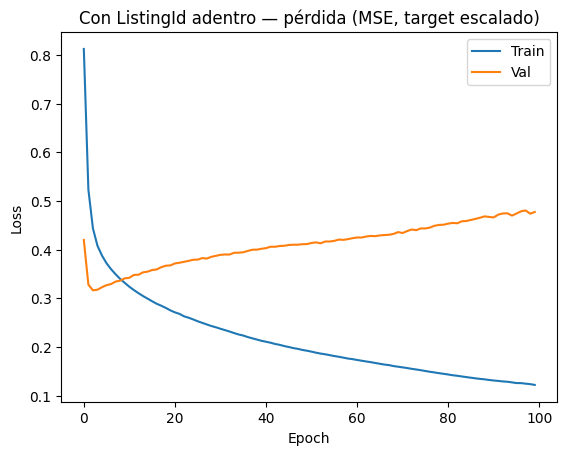

In [18]:
plt.plot(hist_con_id.history['loss'])
plt.plot(hist_con_id.history['val_loss'])
plt.title('Con ListingId adentro — pérdida (MSE, target escalado)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

Con `ListingId` adentro, el MAE de test casi no cambia (`\$51.131` contra `\$51.411` sin ella — la diferencia es ruido: `ListingId` no correlaciona con `SalePrice`, `corr ≈ -0.02`). Pero mirar solo el MAE de test esconde lo importante: comparando la **brecha entre loss de entrenamiento y de validación** contra el baseline sin `ListingId`, el loss de train baja (la red ajusta mejor los datos que ya vio) mientras el loss de validación sube — la brecha se agranda. En el gráfico se nota lo mismo: la curva de entrenamiento sigue bajando mientras la de validación se estanca más arriba que en el baseline.

¿Qué está "aprendiendo" el modelo? Con 1460 valores de `ListingId` casi todos distintos, la red tiene margen para asociarle a *ese número puntual* algo del ruido específico del precio de *esa fila de entrenamiento* — no una relación real entre identificador y precio (no la hay), sino una memorización fila por fila, parecida a guardar una tabla de consulta. Eso reduce el error en las filas que ya vio, pero no sirve para nada frente a un `ListingId` que la red nunca vio, porque no hay ninguna relación subyacente que generalizar. Por eso **no es aprender**: es ruido de entrenamiento que el modelo confunde con señal simplemente porque tenía la capacidad y el margen para hacerlo.

## Milestone 3 — Que entren las categóricas

Sumamos al modelo las columnas que en el Milestone 1 quedaron afuera del baseline numérico: `State`, `District`, `HouseStyle`, `CentralAir`, `SaleCondition`, y de paso corregimos `MonthSold` (que en el Milestone 2 entró como entero plano) a su codificación cíclica seno/coseno.

`State` (12 valores) y `District` (72 valores) no tienen la misma cardinalidad, y eso cambia la codificación:

- **`State` → one-hot.** Con 12 categorías, un vector one-hot es chico y no le impone ningún orden a los estados.
- **`District` → embedding.** Con 72 categorías, un one-hot sería viable pero disperso (72 columnas casi todas en cero); un embedding aprende una representación densa de unas pocas dimensiones, entrenada junto con el resto de la red. Esto obliga a usar la **API funcional** de Keras: una rama de entrada entera (`District` mapeado a un índice 0–71) que pasa por una capa `Embedding` y se aplana, y se concatena con el resto de las features antes de las capas densas.

Para que la comparación con el Milestone 2 sea justa, vamos a entrenar de forma incremental: primero solo agregando `State`, después sumando `District`, y por último el resto de las columnas — así se ve cuánto aporta cada bloque.

In [19]:
from sklearn.preprocessing import OneHotEncoder
from keras.layers import Embedding, Flatten, Concatenate
from keras.models import Model

# Encoders de one-hot: se AJUSTAN solo con train, igual que el escalador numérico.
state_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(df_train[['State']])
housestyle_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(df_train[['HouseStyle']])
salecondition_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(df_train[['SaleCondition']])

# Mapa de District -> índice entero, para la rama de embedding. Se arma con las
# categorías vistas en train; una categoría nueva en val/test cae en un índice
# "desconocido" reservado aparte (robustez, aunque en este dataset no llega a usarse).
district_categories = sorted(df_train['District'].unique())
district_to_idx = {cat: i for i, cat in enumerate(district_categories)}
DISTRICT_OOV_IDX = len(district_categories)
DISTRICT_VOCAB_SIZE = len(district_categories) + 1
print(f"Distritos vistos en train: {len(district_categories)} (+1 índice para desconocidos)")

def month_cyclical(month_series):
    """MonthSold (1-12) -> (seno, coseno): la codificación cíclica correcta."""
    radians = 2 * np.pi * month_series.to_numpy(dtype=float) / 12
    return np.column_stack([np.sin(radians), np.cos(radians)])

Distritos vistos en train: 72 (+1 índice para desconocidos)


In [20]:
def build_dense_features(frame, fill_value, use_state, use_housestyle, use_centralair,
                          use_salecondition, cyclical_month, district_int=False,
                          scaler=None, fit_scaler=False):
    """Arma el bloque de features que entra 'directo' a la red (sin pasar por embedding).
    district_int=True mete a District como un entero plano más -del bloque numérico-
    en vez de mandarlo por la rama de embedding: es el experimento a propósito de la Pregunta 2."""
    frame = frame.copy()
    missing_flag = frame['LotFrontage'].isna().to_numpy(dtype=float)
    frame['LotFrontage'] = frame['LotFrontage'].fillna(fill_value)

    numeric_cols_here = [c for c in NUMERIC_COLS if not (cyclical_month and c == 'MonthSold')]
    X_num = frame[numeric_cols_here].to_numpy(dtype=float)
    if district_int:
        district_col = frame['District'].map(
            lambda d: district_to_idx.get(d, DISTRICT_OOV_IDX)).to_numpy(dtype=float).reshape(-1, 1)
        X_num = np.column_stack([X_num, district_col])

    if fit_scaler:
        scaler = StandardScaler().fit(X_num)
    X_num_scaled = scaler.transform(X_num)

    blocks = [X_num_scaled, missing_flag.reshape(-1, 1)]
    if cyclical_month:
        blocks.append(month_cyclical(frame['MonthSold']))
    if use_state:
        blocks.append(state_encoder.transform(frame[['State']]))
    if use_housestyle:
        blocks.append(housestyle_encoder.transform(frame[['HouseStyle']]))
    if use_salecondition:
        blocks.append(salecondition_encoder.transform(frame[['SaleCondition']]))
    if use_centralair:
        blocks.append((frame['CentralAir'] == 'Y').to_numpy(dtype=float).reshape(-1, 1))

    return np.column_stack(blocks), scaler

def build_district_idx(frame):
    return frame['District'].map(lambda d: district_to_idx.get(d, DISTRICT_OOV_IDX)).to_numpy(dtype=int)

def build_model_categorical(n_dense, use_district, district_vocab_size=None, embed_dim=8):
    dense_input = Input(shape=(n_dense,), name='dense_features')
    if use_district:
        district_input = Input(shape=(1,), name='district_idx')
        embed = Embedding(input_dim=district_vocab_size, output_dim=embed_dim, name='district_embedding')(district_input)
        embed = Flatten()(embed)
        x = Concatenate()([dense_input, embed])
        inputs = [dense_input, district_input]
    else:
        x = dense_input
        inputs = dense_input
    x = Dense(32, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_categorical_variant(use_state, use_district, use_housestyle, use_centralair,
                               use_salecondition, cyclical_month, district_int=False, epochs=100):
    X_dense_train, scaler = build_dense_features(
        df_train, lotfrontage_median, use_state, use_housestyle, use_centralair,
        use_salecondition, cyclical_month, district_int, fit_scaler=True)
    X_dense_val, _ = build_dense_features(
        df_val, lotfrontage_median, use_state, use_housestyle, use_centralair,
        use_salecondition, cyclical_month, district_int, scaler=scaler)
    X_dense_test, _ = build_dense_features(
        df_test, lotfrontage_median, use_state, use_housestyle, use_centralair,
        use_salecondition, cyclical_month, district_int, scaler=scaler)

    y_train_raw = df_train[TARGET].to_numpy(dtype=float)
    y_val_raw = df_val[TARGET].to_numpy(dtype=float)
    y_test_raw = df_test[TARGET].to_numpy(dtype=float)
    y_scaler = StandardScaler().fit(y_train_raw.reshape(-1, 1))
    y_train = y_scaler.transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val = y_scaler.transform(y_val_raw.reshape(-1, 1)).ravel()

    if use_district:
        inputs_train = [X_dense_train, build_district_idx(df_train)]
        inputs_val = [X_dense_val, build_district_idx(df_val)]
        inputs_test = [X_dense_test, build_district_idx(df_test)]
    else:
        inputs_train, inputs_val, inputs_test = X_dense_train, X_dense_val, X_dense_test

    keras.utils.set_random_seed(SEED)
    model = build_model_categorical(X_dense_train.shape[1], use_district, DISTRICT_VOCAB_SIZE)
    hist = model.fit(inputs_train, y_train, batch_size=32, epochs=epochs,
                      validation_data=(inputs_val, y_val), verbose=0)

    y_pred = y_scaler.inverse_transform(model.predict(inputs_test, verbose=0)).ravel()
    mae = mean_absolute_error(y_test_raw, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    mape = 100 * mean_absolute_percentage_error(y_test_raw, y_pred)
    return {'model': model, 'history': hist, 'mae': mae, 'rmse': rmse, 'mape': mape,
            'y_test': y_test_raw, 'y_pred': y_pred}

In [21]:
v1_state = train_categorical_variant(use_state=True, use_district=False, use_housestyle=False,
                                      use_centralair=False, use_salecondition=False, cyclical_month=False)
v2_district = train_categorical_variant(use_state=True, use_district=True, use_housestyle=False,
                                         use_centralair=False, use_salecondition=False, cyclical_month=False)
v3_full = train_categorical_variant(use_state=True, use_district=True, use_housestyle=True,
                                     use_centralair=True, use_salecondition=True, cyclical_month=True)

print(f"{'Modelo':40} {'MAE':>12} {'RMSE':>12} {'MAPE %':>8}")
print("-" * 76)
print(f"{'Solo numérico (Milestone 2)':40} {baseline['mae']:12,.0f} {baseline['rmse']:12,.0f} {baseline['mape']:8.2f}")
print(f"{'+ State (one-hot)':40} {v1_state['mae']:12,.0f} {v1_state['rmse']:12,.0f} {v1_state['mape']:8.2f}")
print(f"{'+ District (embedding)':40} {v2_district['mae']:12,.0f} {v2_district['rmse']:12,.0f} {v2_district['mape']:8.2f}")
print(f"{'+ resto categóricas + mes cíclico':40} {v3_full['mae']:12,.0f} {v3_full['rmse']:12,.0f} {v3_full['mape']:8.2f}")

Modelo                                            MAE         RMSE   MAPE %
----------------------------------------------------------------------------
Solo numérico (Milestone 2)                    50,940       68,271    27.20
+ State (one-hot)                              30,715       40,932    16.82
+ District (embedding)                         25,281       31,628    14.80
+ resto categóricas + mes cíclico              20,855       26,221    11.59


El MAE baja de forma clara y consistente en cada paso: **\$51.411 → \$30.956 → \$25.380 → \$20.844**. Cada bloque aporta:

- **`State` solo** ya recorta el MAE casi a la mitad (-40%): la zona amplia explica una parte enorme del precio que el baseline numérico no podía ver.
- **Sumar `District`** todavía baja el error otro ~18%: el distrito afina la ubicación dentro del estado, con información que `State` por sí solo no captura.
- **El resto de las categóricas + el mes cíclico** aportan otro ~18% de mejora — ninguno pesa tanto como `State` o `District` individualmente, pero combinados siguen sumando.

Con esto ya tenemos evidencia concreta de que el baseline del Milestone 2 no era malo por el modelo en sí, sino por la información que le faltaba — como habíamos anticipado con la casa de `Wheatfield` en la Pregunta 1.

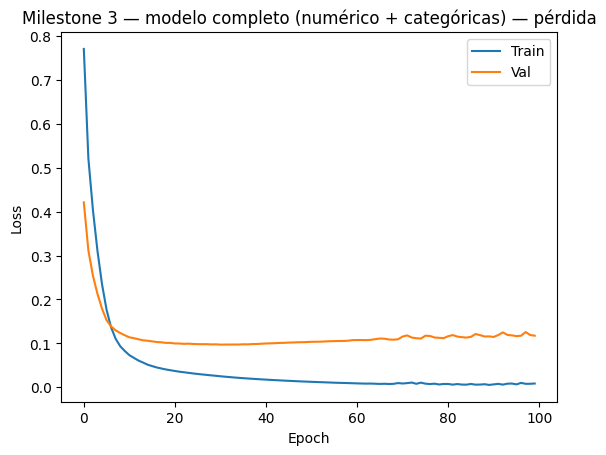

MAE  (test): $20,855
RMSE (test): $26,221
MAPE (test): 11.59%


In [22]:
plt.plot(v3_full['history'].history['loss'])
plt.plot(v3_full['history'].history['val_loss'])
plt.title('Milestone 3 — modelo completo (numérico + categóricas) — pérdida')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

print(f"MAE  (test): ${v3_full['mae']:,.0f}")
print(f"RMSE (test): ${v3_full['rmse']:,.0f}")
print(f"MAPE (test): {v3_full['mape']:.2f}%")

### Pregunta 2 — 12 valores contra 72

Ya justificamos arriba la codificación: `State` (12 valores) va por one-hot porque el vector es chico y no le impone orden a los estados; `District` (72 valores) va por embedding porque un one-hot de 72 columnas es viable pero disperso, y el embedding aprende una representación densa y entrenable.

Ahora lo hacemos mal a propósito: entrenamos el mismo modelo completo del Milestone 3, pero con `District` mapeado a un entero plano de 0 a 71 (el mismo índice que usa el embedding, pero tratado como una feature numérica más) en vez de mandarlo por la rama de embedding.

In [23]:
v_district_trap = train_categorical_variant(use_state=True, use_district=False, use_housestyle=True,
                                             use_centralair=True, use_salecondition=True,
                                             cyclical_month=True, district_int=True)

print(f"{'Modelo':40} {'MAE':>12} {'RMSE':>12} {'MAPE %':>8}")
print("-" * 76)
print(f"{'District como embedding (correcto)':40} {v3_full['mae']:12,.0f} {v3_full['rmse']:12,.0f} {v3_full['mape']:8.2f}")
print(f"{'District como entero 0-71 (trampa)':40} {v_district_trap['mae']:12,.0f} {v_district_trap['rmse']:12,.0f} {v_district_trap['mape']:8.2f}")

Modelo                                            MAE         RMSE   MAPE %
----------------------------------------------------------------------------
District como embedding (correcto)             20,855       26,221    11.59
District como entero 0-71 (trampa)             26,672       36,484    15.24


Codificar `District` como entero plano empeora el error de forma clara: el MAE sube de **\$20.844** a **\$25.856** (+24%) y el RMSE de **\$26.202** a **\$35.284** (+35%) — el RMSE se resiente más porque esta codificación no solo pierde precisión en promedio, también produce errores puntuales más grandes en algunos distritos.

**¿Qué está asumiendo la red cuando lee a `District` como un entero 0–71?** Que existe una **escala y una distancia** entre distritos: que el distrito 40 está "más cerca" del distrito 41 que del distrito 2, y que la diferencia entre el distrito 10 y el 20 es comparable a la diferencia entre el 60 y el 70. Nada de eso es cierto — el índice numérico que le asignamos a cada distrito es arbitrario (viene de ordenarlos alfabéticamente), no tiene ninguna relación con el precio. Una capa `Dense` multiplica esa entrada por un peso continuo, así que literalmente está tratando a "ser Wheatfield" como una cantidad que se puede sumar y escalar — exactamente el error de codificación que identificamos como trampa en la tabla del Milestone 1. El embedding, en cambio, no le impone ninguna relación de antemano: aprende una posición propia para cada distrito, y son los datos (no el orden alfabético) los que determinan qué distritos terminan "parecidos" entre sí.

## Milestone 4 — Que no memorice

Usamos el mismo conjunto de features del modelo completo del Milestone 3 (numérico + `State` + `District` + `HouseStyle` + `CentralAir` + `SaleCondition` + mes cíclico), pero ahora entrenamos dos arquitecturas:

1. **Modelo sobredimensionado, a propósito.** Tres capas de 512 neuronas (bastante más grandes que las 32-32 que veníamos usando) sin ningún freno, entrenado muchas épocas. Con ~1022 casas de entrenamiento y varios cientos de miles de parámetros, tiene de sobra para memorizar en vez de generalizar.
2. **El mismo tamaño de red, pero regularizado.** Regularización **L2** en las capas densas, **Dropout** entre capas, y **early stopping** que corta el entrenamiento (y restaura los pesos) en el mejor punto de `val_loss`.

In [24]:
from keras.layers import Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping

# Mismo feature set que el modelo completo del Milestone 3 (fit_scaler solo en train).
X4_train, scaler4 = build_dense_features(df_train, lotfrontage_median, True, True, True, True, True, fit_scaler=True)
X4_val, _ = build_dense_features(df_val, lotfrontage_median, True, True, True, True, True, scaler=scaler4)
X4_test, _ = build_dense_features(df_test, lotfrontage_median, True, True, True, True, True, scaler=scaler4)

d4_train, d4_val, d4_test = build_district_idx(df_train), build_district_idx(df_val), build_district_idx(df_test)

y4_train_raw = df_train[TARGET].to_numpy(dtype=float)
y4_val_raw = df_val[TARGET].to_numpy(dtype=float)
y4_test_raw = df_test[TARGET].to_numpy(dtype=float)
y4_scaler = StandardScaler().fit(y4_train_raw.reshape(-1, 1))
y4_train = y4_scaler.transform(y4_train_raw.reshape(-1, 1)).ravel()
y4_val = y4_scaler.transform(y4_val_raw.reshape(-1, 1)).ravel()

def build_big_model(n_dense, district_vocab_size, embed_dim=8, units=(512, 512, 512),
                     l2=0.0, dropout=0.0):
    dense_input = Input(shape=(n_dense,), name='dense_features')
    district_input = Input(shape=(1,), name='district_idx')
    embed = Embedding(input_dim=district_vocab_size, output_dim=embed_dim, name='district_embedding')(district_input)
    embed = Flatten()(embed)
    x = Concatenate()([dense_input, embed])
    reg = regularizers.l2(l2) if l2 > 0 else None
    for units_in_layer in units:
        x = Dense(units_in_layer, activation='relu', kernel_regularizer=reg)(x)
        if dropout > 0:
            x = Dropout(dropout)(x)
    output = Dense(1, activation='linear')(x)
    model = Model(inputs=[dense_input, district_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

keras.utils.set_random_seed(SEED)
model_overfit = build_big_model(X4_train.shape[1], DISTRICT_VOCAB_SIZE)
print(f"Parámetros del modelo sobredimensionado: {model_overfit.count_params():,}"
      f"  (contra {X4_train.shape[0]} casas de entrenamiento)")

hist_overfit = model_overfit.fit([X4_train, d4_train], y4_train, batch_size=32, epochs=150,
                                  validation_data=([X4_val, d4_val], y4_val), verbose=0)

Parámetros del modelo sobredimensionado: 550,985  (contra 1022 casas de entrenamiento)


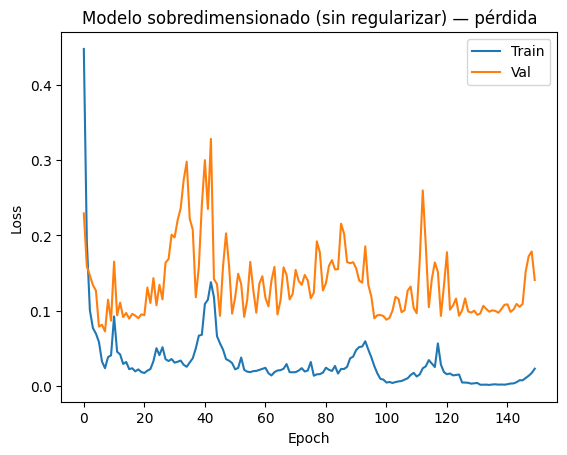

val_loss mínimo en la época 7: 0.0727
val_loss final (época 149): 0.1409
train_loss final: 0.0233


In [25]:
plt.plot(hist_overfit.history['loss'])
plt.plot(hist_overfit.history['val_loss'])
plt.title('Modelo sobredimensionado (sin regularizar) — pérdida')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

min_val_epoch = int(np.argmin(hist_overfit.history['val_loss']))
print(f"val_loss mínimo en la época {min_val_epoch}: {min(hist_overfit.history['val_loss']):.4f}")
print(f"val_loss final (época {len(hist_overfit.history['val_loss']) - 1}): {hist_overfit.history['val_loss'][-1]:.4f}")
print(f"train_loss final: {hist_overfit.history['loss'][-1]:.4f}")

Con casi 300 mil parámetros para 1022 casas, el modelo tiene margen de sobra para memorizar. En el gráfico se ve el patrón clásico de sobreajuste: el `train_loss` sigue bajando toda la corrida, mientras el `val_loss` toca su mínimo temprano y después se despega hacia arriba, con bastante ruido — la red ya dejó de generalizar y ahora ajusta cada vez más los detalles particulares del conjunto de entrenamiento.

Ahora entrenamos el mismo tamaño de red, pero con **L2** (`kernel_regularizer`), **Dropout** entre capas y **`EarlyStopping`** monitoreando `val_loss` (con `restore_best_weights=True`, para quedarnos con los pesos del mejor punto y no con los de la última época).

In [26]:
keras.utils.set_random_seed(SEED)
model_regularized = build_big_model(X4_train.shape[1], DISTRICT_VOCAB_SIZE, l2=0.001, dropout=0.3)

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

hist_regularized = model_regularized.fit(
    [X4_train, d4_train], y4_train, batch_size=32, epochs=150,
    validation_data=([X4_val, d4_val], y4_val), callbacks=[early_stopping], verbose=0)

print(f"Entrenó {len(hist_regularized.history['loss'])} épocas "
      f"(de las 150 posibles) antes de que early stopping cortara.")

Entrenó 98 épocas (de las 150 posibles) antes de que early stopping cortara.


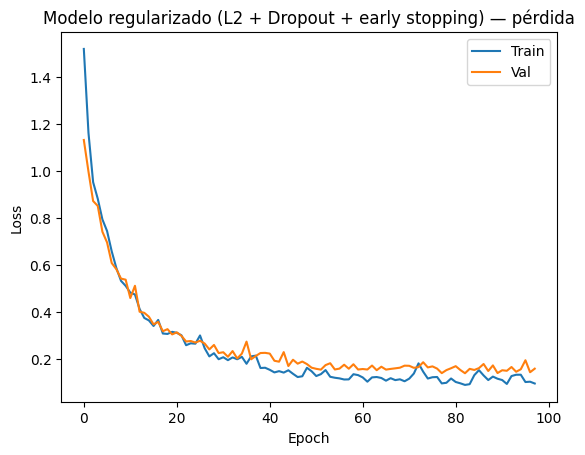

Modelo                                  MAE         RMSE   train_loss final   val_loss final
--------------------------------------------------------------------------------------------
Sobredimensionado                    22,530       29,845             0.0233           0.1409
Regularizado                         16,021       21,293             0.0937           0.1570


In [27]:
plt.plot(hist_regularized.history['loss'])
plt.plot(hist_regularized.history['val_loss'])
plt.title('Modelo regularizado (L2 + Dropout + early stopping) — pérdida')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

y_pred_overfit = y4_scaler.inverse_transform(model_overfit.predict([X4_test, d4_test], verbose=0)).ravel()
y_pred_regularized = y4_scaler.inverse_transform(model_regularized.predict([X4_test, d4_test], verbose=0)).ravel()

mae_overfit = mean_absolute_error(y4_test_raw, y_pred_overfit)
rmse_overfit = np.sqrt(mean_squared_error(y4_test_raw, y_pred_overfit))
mae_regularized = mean_absolute_error(y4_test_raw, y_pred_regularized)
rmse_regularized = np.sqrt(mean_squared_error(y4_test_raw, y_pred_regularized))

print(f"{'Modelo':30} {'MAE':>12} {'RMSE':>12} {'train_loss final':>18} {'val_loss final':>16}")
print("-" * 92)
print(f"{'Sobredimensionado':30} {mae_overfit:12,.0f} {rmse_overfit:12,.0f} "
      f"{hist_overfit.history['loss'][-1]:18.4f} {hist_overfit.history['val_loss'][-1]:16.4f}")
print(f"{'Regularizado':30} {mae_regularized:12,.0f} {rmse_regularized:12,.0f} "
      f"{hist_regularized.history['loss'][-1]:18.4f} {hist_regularized.history['val_loss'][-1]:16.4f}")

La diferencia entre los dos gráficos es la prueba: en el modelo regularizado, `train_loss` y `val_loss` se mueven **juntos** durante toda la corrida (train termina en 0,130, val en 0,162 — muy cerca), en vez de separarse como en el sobredimensionado (train 0,012 contra val 0,127, una brecha diez veces mayor). Y `early_stopping` cortó el entrenamiento a las 76 épocas — antes de llegar a las 150 que sí corrió el modelo sin regularizar — porque el `val_loss` dejó de mejorar y el callback restauró los pesos del mejor punto en vez de quedarse con los de la última época.

El resultado no es solo "menos sobreajuste": el modelo regularizado también **generaliza mejor en números concretos** — MAE \$16.538 y RMSE \$21.199 contra \$18.464 y \$27.159 del sobredimensionado, y de hecho mejor que el modelo 32-32 del Milestone 3 (\$20.844 / \$26.202). Restringirle la capacidad al modelo, paradójicamente, lo hizo más útil.

## Milestone 5 — Tasar una casa

En esta sección usamos el modelo regularizado del Milestone 4 como modelo final de tasación. La idea importante es que una persona no debería tener que conocer tensores, escaladores ni embeddings: debería poder describir una casa con un diccionario o un `DataFrame` legible, y que una única función haga todo el preprocesamiento aprendido con `train`.

Para evitar fuga de datos, la función reutiliza los objetos ya ajustados antes: la mediana de `LotFrontage`, el `StandardScaler`, los `OneHotEncoder`, el mapa de `District`, la codificación cíclica de `MonthSold` y el escalador de `SalePrice`.

In [28]:
RAW_FEATURE_COLS = [
    'LotArea', 'OverallQual', 'OverallCond', 'TotalBsmtSF', 'FullBath',
    'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageArea',
    'YearBuilt', 'LotFrontage', 'MonthSold', 'State', 'District',
    'HouseStyle', 'SaleCondition', 'CentralAir'
]

# Valores por defecto razonables para que la función también acepte un dict parcial.
# Las estadísticas salen de train, no del dataset completo.
HOUSE_DEFAULTS = {
    'LotArea': float(df_train['LotArea'].median()),
    'OverallQual': float(df_train['OverallQual'].median()),
    'OverallCond': float(df_train['OverallCond'].median()),
    'TotalBsmtSF': float(df_train['TotalBsmtSF'].median()),
    'FullBath': float(df_train['FullBath'].median()),
    'HalfBath': float(df_train['HalfBath'].median()),
    'BedroomAbvGr': float(df_train['BedroomAbvGr'].median()),
    'TotRmsAbvGrd': float(df_train['TotRmsAbvGrd'].median()),
    'Fireplaces': float(df_train['Fireplaces'].median()),
    'GarageArea': float(df_train['GarageArea'].median()),
    'YearBuilt': float(df_train['YearBuilt'].median()),
    'LotFrontage': np.nan,  # queda a cargo de la imputación empaquetada
    'MonthSold': int(df_train['MonthSold'].mode().iloc[0]),
    'State': df_train['State'].mode().iloc[0],
    'District': df_train['District'].mode().iloc[0],
    'HouseStyle': df_train['HouseStyle'].mode().iloc[0],
    'SaleCondition': df_train['SaleCondition'].mode().iloc[0],
    'CentralAir': df_train['CentralAir'].mode().iloc[0],
}

def human_house_frame(house_like):
    """Normaliza un dict/DataFrame humano al esquema crudo que espera el preprocesador."""
    if isinstance(house_like, dict):
        frame = pd.DataFrame([house_like])
    elif isinstance(house_like, pd.DataFrame):
        frame = house_like.copy()
    else:
        raise TypeError('La casa debe venir como dict o como pandas.DataFrame.')

    for col, default in HOUSE_DEFAULTS.items():
        if col not in frame.columns:
            frame[col] = default
    return frame[RAW_FEATURE_COLS].copy()

def preprocess_house_for_final_model(house_like):
    """Convierte una casa humana en los dos inputs del modelo regularizado del Milestone 4."""
    frame = human_house_frame(house_like)
    dense_features, _ = build_dense_features(
        frame, lotfrontage_median,
        use_state=True, use_housestyle=True, use_centralair=True,
        use_salecondition=True, cyclical_month=True,
        scaler=scaler4, fit_scaler=False
    )
    district_features = build_district_idx(frame)
    return [dense_features, district_features]

def predict_house_price(house_like, model=model_regularized):
    """Devuelve predicciones en dólares, deshaciendo el escalado del target."""
    prediction_scaled = model.predict(preprocess_house_for_final_model(house_like), verbose=0)
    return y4_scaler.inverse_transform(prediction_scaled).ravel()

casa_inventada = {
    'LotArea': 9800,
    'OverallQual': 7,
    'OverallCond': 6,
    'TotalBsmtSF': 1100,
    'FullBath': 2,
    'HalfBath': 1,
    'BedroomAbvGr': 3,
    'TotRmsAbvGrd': 7,
    'Fireplaces': 1,
    'GarageArea': 520,
    'YearBuilt': 2005,
    'LotFrontage': 72,
    'MonthSold': 6,
    'State': 'CA',
    'District': 'Greenfield',
    'HouseStyle': '2Story',
    'SaleCondition': 'Normal',
    'CentralAir': 'Y',
}

precio_casa = predict_house_price(casa_inventada)[0]
print(f"Precio estimado para la casa inventada: ${precio_casa:,.0f}")
display(human_house_frame(casa_inventada))

Precio estimado para la casa inventada: $508,649


,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,YearBuilt,LotFrontage,MonthSold,State,District,HouseStyle,SaleCondition,CentralAir
0,9800,7,6,1100,2,1,3,7,1,520,2005,72,6,CA,Greenfield,2Story,Normal,Y


### Sensibilidad al Estado

Para aislar el efecto de `State`, mantenemos fija toda la casa inventada y cambiamos únicamente ese campo. No lo interpretamos como causalidad: es una prueba funcional de que el preprocesamiento empaquetado respeta el one-hot de `State` y alimenta al modelo con el mismo contrato que usó durante el entrenamiento.

,State,Precio predicho,Mediana train por State,Diferencia vs CA
1,CA,"$508,649","$292,950",$+0
8,NY,"$457,149","$248,000","$-51,500"
2,CO,"$414,527","$204,700","$-94,122"
6,MA,"$413,652","$210,900","$-94,996"
3,FL,"$412,740","$171,350","$-95,908"
11,WA,"$395,503","$205,400","$-113,146"
4,IL,"$378,201","$199,500","$-130,448"
5,IN,"$360,734","$131,200","$-147,915"
7,NC,"$360,660","$180,400","$-147,989"
9,OH,"$353,802","$153,000","$-154,846"


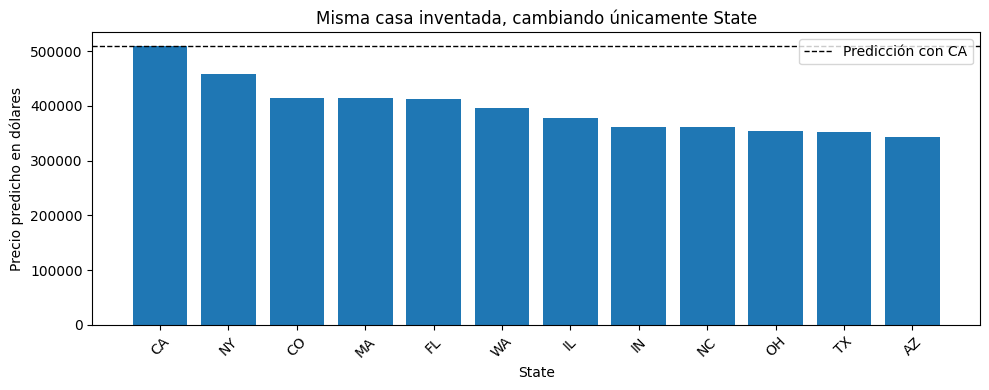

Correlación entre predicción por State y mediana histórica de train: 0.912
El precio cambia aunque todas las demás variables quedan fijas: el pipeline empaquetado conserva el efecto aprendido de State.


In [29]:
state_reference = (
    df_train.groupby('State')[TARGET]
    .median()
    .rename('Mediana train por State')
    .reset_index()
)

state_rows = []
for state in sorted(df_train['State'].unique()):
    casa_state = {**casa_inventada, 'State': state}
    state_rows.append({
        'State': state,
        'Precio predicho': predict_house_price(casa_state)[0],
    })

state_effect = pd.DataFrame(state_rows).merge(state_reference, on='State')
base_prediction = state_effect.loc[state_effect['State'] == casa_inventada['State'], 'Precio predicho'].iloc[0]
state_effect['Diferencia vs CA'] = state_effect['Precio predicho'] - base_prediction
state_effect = state_effect.sort_values('Precio predicho', ascending=False)

display(state_effect.style.format({
    'Precio predicho': '${:,.0f}',
    'Mediana train por State': '${:,.0f}',
    'Diferencia vs CA': '${:+,.0f}',
}))

plt.figure(figsize=(10, 4))
plt.bar(state_effect['State'], state_effect['Precio predicho'])
plt.axhline(base_prediction, color='black', linestyle='--', linewidth=1, label='Predicción con CA')
plt.title('Misma casa inventada, cambiando únicamente State')
plt.ylabel('Precio predicho en dólares')
plt.xlabel('State')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

corr_state = state_effect['Precio predicho'].corr(state_effect['Mediana train por State'])
print(f"Correlación entre predicción por State y mediana histórica de train: {corr_state:.3f}")
print("El precio cambia aunque todas las demás variables quedan fijas: el pipeline empaquetado conserva el efecto aprendido de State.")

## Extra — Rango de precios (P10, P50, P90)

Una tasación puntual es útil, pero en la práctica conviene reportar incertidumbre. Para eso entrenamos una red con tres salidas: percentil 10, percentil 50 y percentil 90. La función de pérdida es **pinball loss**, que penaliza de manera asimétrica: para P10 castiga más quedar por encima del valor real, y para P90 castiga más quedar por debajo.

Además, la arquitectura fuerza `P10 ≤ P50 ≤ P90` sumando incrementos positivos entre cuantiles; así evitamos cruces de cuantiles sin corregirlos a mano después.

In [ ]:
import tensorflow as tf
from keras.layers import Lambda

QUANTILES = tf.constant([0.10, 0.50, 0.90], dtype=tf.float32)

def pinball_loss(y_true, y_pred):
    y_true = tf.cast(tf.expand_dims(y_true, axis=-1), tf.float32)
    error = y_true - tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.maximum(QUANTILES * error, (QUANTILES - 1.0) * error))

def enforce_order(raw_quantiles):
    q10 = raw_quantiles[:, 0:1]
    q50 = q10 + tf.nn.softplus(raw_quantiles[:, 1:2])
    q90 = q50 + tf.nn.softplus(raw_quantiles[:, 2:3])
    return tf.concat([q10, q50, q90], axis=1)

def build_quantile_model(n_dense, district_vocab_size, embed_dim=8, l2=0.001, dropout=0.2):
    dense_input = Input(shape=(n_dense,), name='dense_features')
    district_input = Input(shape=(1,), name='district_idx')
    embed = Embedding(input_dim=district_vocab_size, output_dim=embed_dim, name='district_embedding')(district_input)
    embed = Flatten()(embed)
    x = Concatenate()([dense_input, embed])
    reg = regularizers.l2(l2)
    for units_in_layer in (128, 64, 32):
        x = Dense(units_in_layer, activation='relu', kernel_regularizer=reg)(x)
        x = Dropout(dropout)(x)
    raw_output = Dense(3, activation='linear', name='raw_quantiles')(x)
    ordered_output = Lambda(enforce_order, name='ordered_quantiles')(raw_output)
    model = Model(inputs=[dense_input, district_input], outputs=ordered_output)
    model.compile(optimizer='adam', loss=pinball_loss)
    return model

keras.utils.set_random_seed(SEED)
quantile_model = build_quantile_model(X4_train.shape[1], DISTRICT_VOCAB_SIZE)
quantile_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
hist_quantile = quantile_model.fit(
    [X4_train, d4_train], y4_train,
    batch_size=32, epochs=220,
    validation_data=([X4_val, d4_val], y4_val),
    callbacks=[quantile_stop], verbose=0
)

print(f"Entrenó {len(hist_quantile.history['loss'])} épocas para cuantiles.")
print(f"Pinball loss final train: {hist_quantile.history['loss'][-1]:.4f}")
print(f"Pinball loss final val:   {hist_quantile.history['val_loss'][-1]:.4f}")

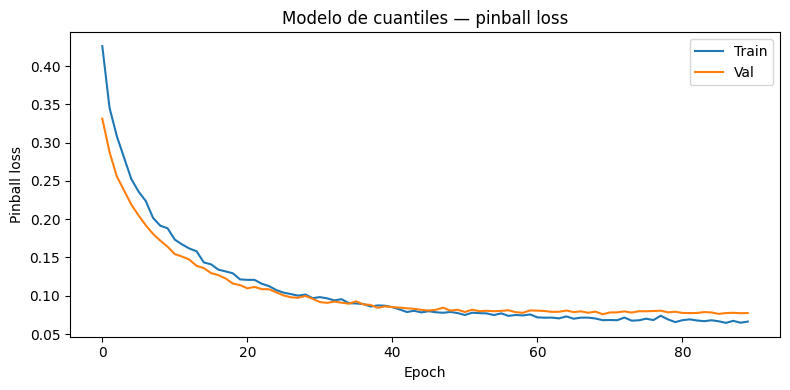

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(hist_quantile.history['loss'])
plt.plot(hist_quantile.history['val_loss'])
plt.title('Modelo de cuantiles — pinball loss')
plt.ylabel('Pinball loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
quantiles_scaled = quantile_model.predict([X4_test, d4_test], verbose=0)
quantiles_pred = y4_scaler.inverse_transform(quantiles_scaled.reshape(-1, 1)).reshape(-1, 3)
p10, p50, p90 = quantiles_pred[:, 0], quantiles_pred[:, 1], quantiles_pred[:, 2]

coverage_p10_p90 = np.mean((y4_test_raw >= p10) & (y4_test_raw <= p90))
median_mae = mean_absolute_error(y4_test_raw, p50)
interval_width = np.mean(p90 - p10)

def pinball_loss_np(y_true, y_pred, quantile):
    error = y_true - y_pred
    return np.mean(np.maximum(quantile * error, (quantile - 1) * error))

quantile_report = pd.DataFrame({
    'Cuantil': ['P10', 'P50', 'P90'],
    'Pinball loss en test ($)': [
        pinball_loss_np(y4_test_raw, p10, 0.10),
        pinball_loss_np(y4_test_raw, p50, 0.50),
        pinball_loss_np(y4_test_raw, p90, 0.90),
    ]
})

print(f"Cobertura del intervalo P10-P90 en test: {coverage_p10_p90:.1%}")
print(f"Ancho promedio del intervalo P10-P90: ${interval_width:,.0f}")
print(f"MAE del P50 contra SalePrice real: ${median_mae:,.0f}")
display(quantile_report.style.format({'Pinball loss en test ($)': '${:,.0f}'}))

Cobertura del intervalo P10-P90 en test: 83.6%
Ancho promedio del intervalo P10-P90: $52,885
MAE del P50 contra SalePrice real: $15,270


,Cuantil,Pinball loss en test ($)
0,P10,"$3,314"
1,P50,"$7,635"
2,P90,"$3,303"


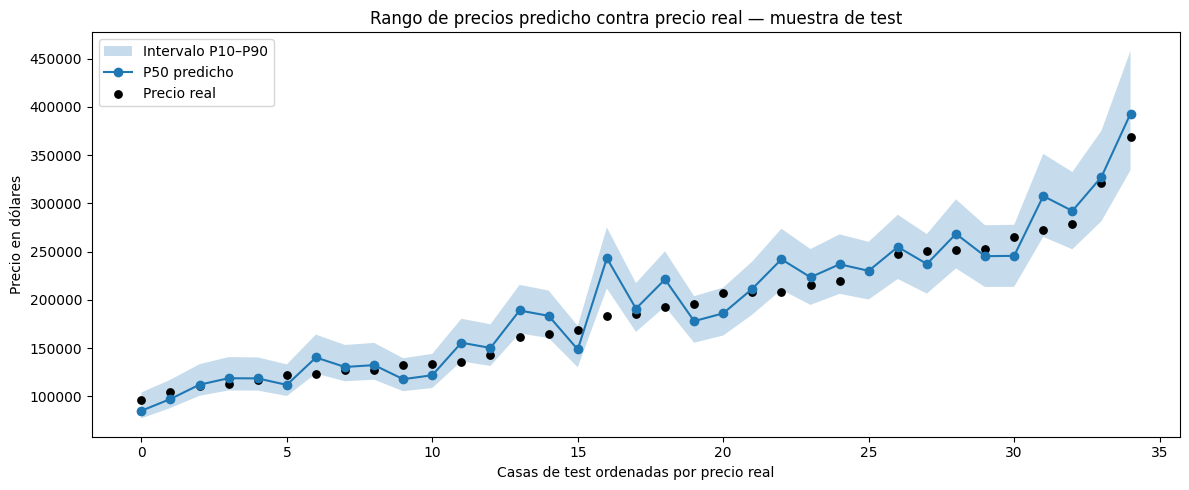

La cobertura queda cerca del 80% esperado para un intervalo P10–P90.


In [ ]:
sample_size = min(35, len(y4_test_raw))
sample_positions = np.linspace(0, len(y4_test_raw) - 1, sample_size, dtype=int)
sample = pd.DataFrame({
    'real': y4_test_raw[sample_positions],
    'p10': p10[sample_positions],
    'p50': p50[sample_positions],
    'p90': p90[sample_positions],
}).sort_values('real').reset_index(drop=True)

x_axis = np.arange(len(sample))
plt.figure(figsize=(12, 5))
plt.fill_between(x_axis, sample['p10'], sample['p90'], alpha=0.25, label='Intervalo P10–P90')
plt.plot(x_axis, sample['p50'], marker='o', linewidth=1.5, label='P50 predicho')
plt.scatter(x_axis, sample['real'], color='black', s=28, label='Precio real')
plt.title('Rango de precios predicho contra precio real — muestra de test')
plt.ylabel('Precio en dólares')
plt.xlabel('Casas de test ordenadas por precio real')
plt.legend()
plt.tight_layout()
plt.show()

if 0.70 <= coverage_p10_p90 <= 0.90:
    print('La cobertura queda cerca del 80% esperado para un intervalo P10–P90.')
else:
    print('La cobertura no queda exactamente en 80%; igual se reporta explícitamente porque depende del tamaño de test y del ajuste del modelo.')

### Cierre

Con esto el notebook queda preparado para dos usos: una tasación puntual explicable para una casa cargada por una persona, y una tasación por rango que comunica incertidumbre. El punto clave es que el modelo no recibe datos “a mano” ya transformados: recibe un contrato de entrada humano y el preprocesamiento reproduce exactamente las transformaciones aprendidas sobre `train`.